Collecte de données

Utilisation d'un scraper web qui collecte des citations depuis le site quotes.toscrape.com. Il utilise la bibliothèque Requests pour télécharger les pages et BeautifulSoup pour analyser le code HTML.

  À chaque page, il récupère toutes les citations et leurs auteurs .

  Pour chaque auteur, il suit le lien vers sa page personnelle afin d’extraire sa date de naissance et son lieu de naissance.    Toutes ces informations sont stockées dans une liste sous forme de dictionnaires.

  Le code continue automatiquement vers la page suivante tant qu’il existe un bouton Next.

  À la fin, les données sont transformées en un DataFrame Pandas puis sauvegardées dans un fichier CSV appelé citations.csv.

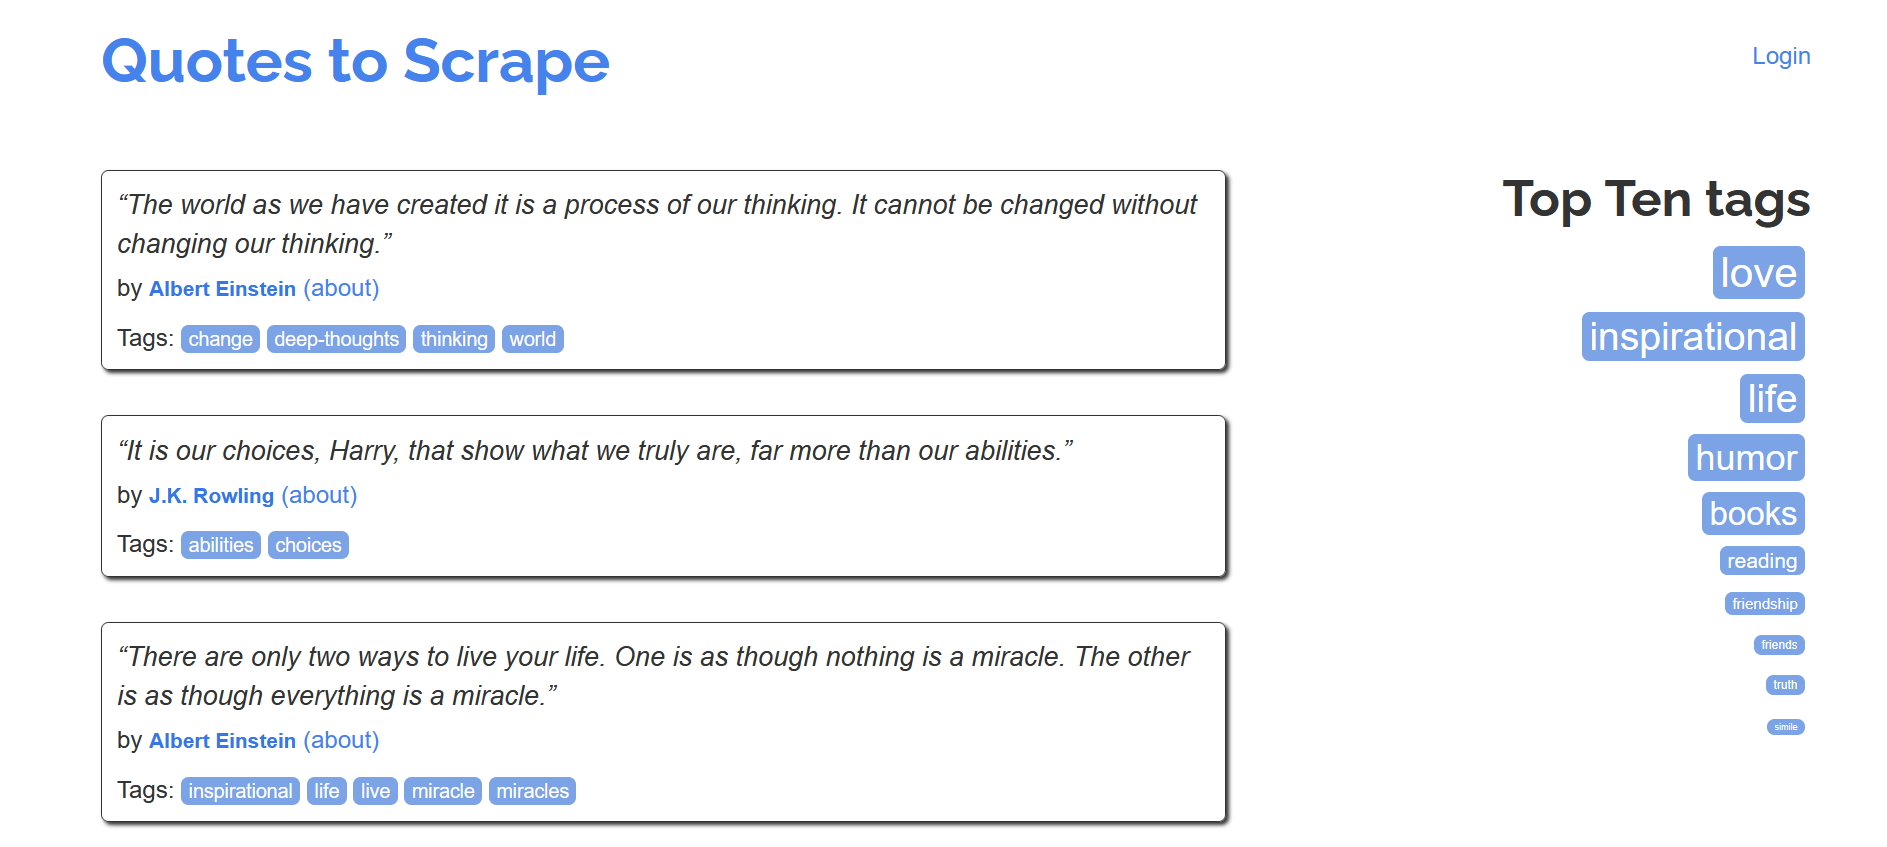


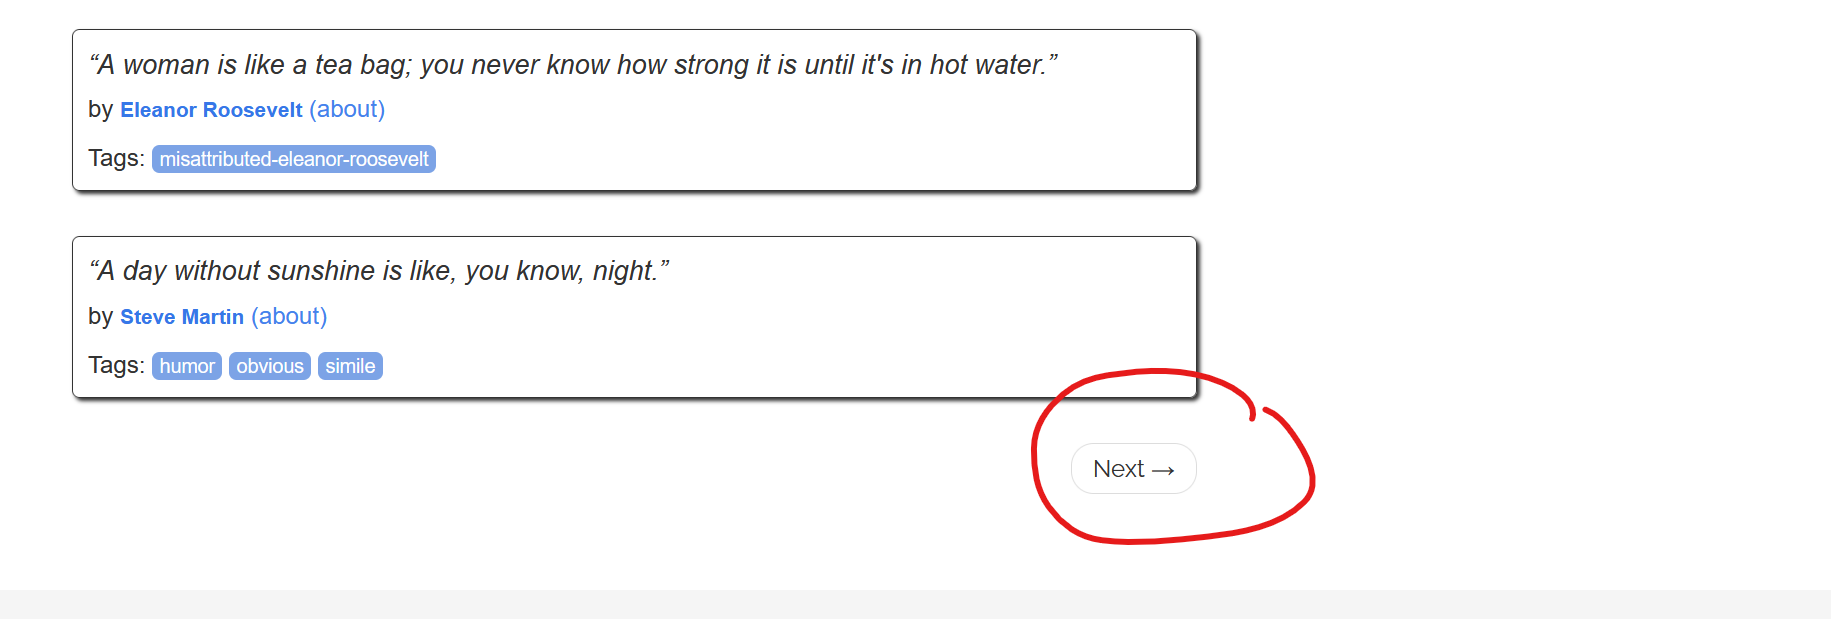

In [2]:
import requests
import pandas as pd
from bs4 import BeautifulSoup
list=[]
url_base="https://quotes.toscrape.com/"
url=url_base
while True:

  r=requests.get(url)
  soup = BeautifulSoup(r.text, "html.parser")

  citations=soup.find_all("div",class_='quote')

  for i in citations:
    text=i.find("span",class_="text").get_text()

    auteur=i.find("small",class_="author").get_text()

    url1=i.find("a")['href']

    url2=url_base+url1

    r1=requests.get(url2)

    soup1=BeautifulSoup(r1.text,"html.parser")

    date_naissance=soup1.find("span",class_="author-born-date").get_text()

    lieu_naissance=soup1.find("span",class_="author-born-location").get_text()

    list.append({
        "Citations":text,
        "Auteur":auteur,
        "Date_Naissance":date_naissance,
        "Lieu_Naissance":lieu_naissance
    })

  boutton_next=soup.find("li",class_="next")

  if boutton_next:
    page_next=boutton_next.find("a")['href']
    url=url_base+page_next
  else:
    break



df = pd.DataFrame(list)
df.to_csv("citations.csv")

df


,Citations,Auteur,Date_Naissance,Lieu_Naissance
0,“The world as we have created it is a process ...,Albert Einstein,"March 14, 1879","in Ulm, Germany"
1,"“It is our choices, Harry, that show what we t...",J.K. Rowling,"July 31, 1965","in Yate, South Gloucestershire, England, The U..."
2,“There are only two ways to live your life. On...,Albert Einstein,"March 14, 1879","in Ulm, Germany"
3,"“The person, be it gentleman or lady, who has ...",Jane Austen,"December 16, 1775","in Steventon Rectory, Hampshire, The United Ki..."
4,"“Imperfection is beauty, madness is genius and...",Marilyn Monroe,"June 01, 1926",in The United States
...,...,...,...,...
95,“You never really understand a person until yo...,Harper Lee,"April 28, 1926","in Monroeville, Alabama, The United States"
96,“You have to write the book that wants to be w...,Madeleine L'Engle,"November 29, 1918","in New York City, New York, The United States"
97,“Never tell the truth to people who are not wo...,Mark Twain,"November 30, 1835","in Florida, Missouri, The United States"
98,"“A person's a person, no matter how small.”",Dr. Seuss,"March 02, 1904","in Springfield, MA, The United States"


Traitement des données

Quotes to scrape fourni les citations et les informations sur les auteurs en Anglais.
Comme Data Cleaning nous avons procédé à une traduction de ces dernières en francais.

In [3]:
!pip install deep-translator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 2.7 MB/s eta 0:00:00


In [ ]:
from deep_translator import GoogleTranslator

def traduire_texte(texte, langue_cible):
    try:
        if pd.isna(texte):
            return texte
        return GoogleTranslator(source='auto', target=langue_cible).translate(str(texte))
    except Exception:
        return texte


colonnes = ["Citations", "Auteur", "Lieu_Naissance"]

for col in colonnes:
    print(f"Traduction de la colonne {col} vers le français…")

    df[col] = df[col].apply(lambda x: traduire_texte(x, "fr"))


df.to_csv("citations_fr.csv", index=False)

df.head()


Traduction de la colonne Citations vers le français…
Traduction de la colonne Auteur vers le français…
Traduction de la colonne Lieu_Naissance vers le français…


,Citations,Auteur,Date_Naissance,Lieu_Naissance
0,"""Le monde tel que nous l'avons créé est un pro...",Albert Einstein,"March 14, 1879","à Ulm, Allemagne"
1,"""Ce sont nos choix, Harry, qui montrent ce que...",J.K. J.K. Rowling,"July 31, 1965","à Yate, South Gloucestershire, Angleterre, Roy..."
2,"""Il n'y a que deux façons de vivre sa vie. L'u...",Albert Einstein,"March 14, 1879","à Ulm, Allemagne"
3,"""La personne, qu'il s'agisse d'un gentleman ou...",Jane Austen,"December 16, 1775","au presbytère de Steventon, Hampshire, Royaume..."
4,"""L'imperfection est la beauté, la folie est le...",Marilyn Monroe,"June 01, 1926",aux États-Unis


Exploration de données

Après  la collecte et le nettoyage de notre dataset, la question qui se pose: que faire avec de telles données?

 Nous avons donc décider de compter combien de citations chaque auteur possède. Nous utilisons Seaborn pour compter automatiquement les auteurs et afficher un graphique en barres horizontales. Chaque barre correspond à un auteur, et sa longueur indique le nombre de citations. Le titre et les couleurs rendent le graphique plus clair et agréable à lire. »

/tmp/ipykernel_1154/3188459774.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Auteur", data=df, palette="viridis")


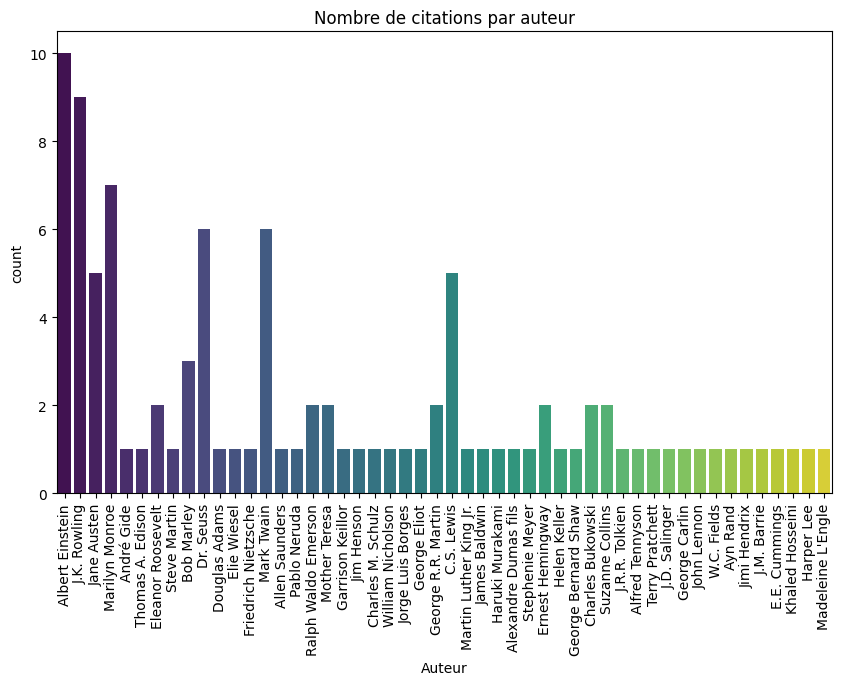

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6)) # definir la taille de la figure
sns.countplot(x="Auteur", data=df, palette="viridis")

plt.title("Nombre de citations par auteur")
plt.xticks(rotation=90)
plt.show()


Analyse

Pour lanalyse de notre dataset,nous avons décidé de de rajouter une colonne "Longueur" à notre dataframe.Elle indique le nombre de caractères de chaque citations.
Ces données, par la suite, nous permettrons de savoir quel auteur écrit les citations les plus longues.

Longueur moyenne des citations par auteur :
Auteur
Pablo Neruda              319.000000
Bob Marley                286.333333
J.D. Salinger             241.000000
Marilyn Monroe            240.857143
Elie Wiesel               224.000000
C.S. Lewis                184.400000
Jane Austen               171.800000
Ralph Waldo Emerson       168.500000
Charles Bukowski          161.500000
Helen Keller              153.000000
Harper Lee                148.000000
Madeleine L'Engle         139.000000
Jim Henson                134.000000
Terry Pratchett           125.000000
Garrison Keillor          123.000000
J.K. Rowling              118.444444
James Baldwin             118.000000
John Lennon               117.000000
Haruki Murakami           110.000000
Dr. Seuss                 107.666667
Jimi Hendrix              103.000000
Douglas Adams              95.000000
Albert Einstein            93.700000
Alfred Tennyson            93.000000
George R.R. Martin         91.000000
Friedrich Nietzsche     

/tmp/ipykernel_1154/3331307362.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="Longueur", x="Auteur", data=df, estimator="mean", palette="viridis")


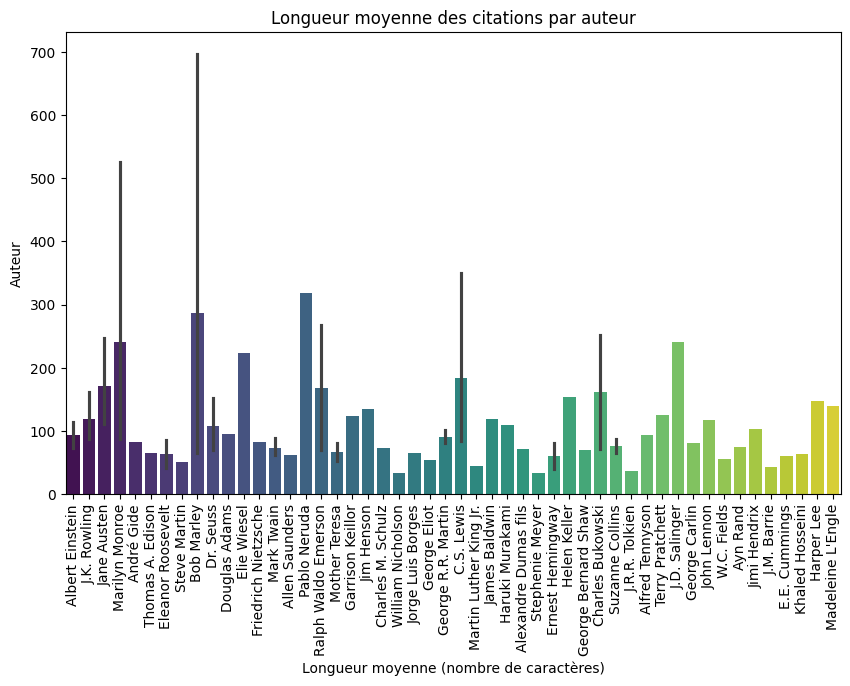

In [17]:
df["Longueur"] = df["Citations"].apply(len)
moyenne_par_auteur = df.groupby("Auteur")["Longueur"].mean().sort_values(ascending=False)
print("Longueur moyenne des citations par auteur :")
print(moyenne_par_auteur)

# 5. Visualiser avec un graphique
plt.figure(figsize=(10,6))
sns.barplot(y="Longueur", x="Auteur", data=df, estimator="mean", palette="viridis")
plt.title("Longueur moyenne des citations par auteur")
plt.xlabel("Longueur moyenne (nombre de caractères)")
plt.ylabel("Auteur")
plt.xticks(rotation=90)
plt.show()



In [7]:
# création de la variable cible pour le machine learning
df["label"] = df["Longueur"].apply(lambda x: 1 if x > 120 else 0)

df[["Citations","Longueur","label"]].head()

,Citations,Longueur,label
0,“The world as we have created it is a process ...,115,0
1,"“It is our choices, Harry, that show what we t...",85,0
2,“There are only two ways to live your life. On...,131,1
3,"“The person, be it gentleman or lady, who has ...",104,0
4,"“Imperfection is beauty, madness is genius and...",111,0


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english")

X = vectorizer.fit_transform(df["Citations"])
y = df["label"]

print(X.shape)

(100, 501)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(80, 501)
(20, 501)


In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [12]:
y_pred = model.predict(X_test)

print(y_pred)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [13]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.75


In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

from sklearn.metrics import accuracy_score

print("Random Forest accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest accuracy: 0.75


In [16]:
new_quote = ["Life is beautiful when you believe in yourself"]

new_vec = vectorizer.transform(new_quote)

prediction = model.predict(new_vec)

if prediction[0] == 1:
    print("Long quote")
else:
    print("Short quote")

Short quote
